> **2026-08 revision.** Vectorized, tested implementations of this notebook's logic live in [`../impact_model.py`](../impact_model.py) (see `../tests/`): loop-free book walks, scale-free cross-symbol pooling (bps premiums, depth-relative sizes), bootstrap CIs for the exponent, and the KKT allocator with optimality tests on a synthetic MBP-10 fixture.
> Note the scope caveat in the README: snapshot book-walk premiums measure the virtual cost of displayed liquidity, not realized metaorder impact.


First, I import the data:

In [1]:
import pandas as pd
import glob
import os

def load_and_index_csvs(dir_paths):
    # Load CSVs
    dfs = []
    for dir_path in dir_paths:
        expanded_dir = os.path.expanduser(dir_path)
        pattern = os.path.join(expanded_dir, '**', '*.csv')
        for filepath in glob.glob(pattern, recursive=True):
            df = pd.read_csv(filepath)
            dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    
    # Convert ts_event nanoseconds to datetime
    combined['ts_event_dt'] = pd.to_datetime(combined['ts_event'], unit='ns')
    # Extract date for indexing
    combined['date'] = pd.to_datetime(combined['ts_event'], unit='ns').dt.date

    # Ensure overall chronological order
    combined.sort_values(['symbol', 'ts_event'], inplace=True)
    
    # Set MultiIndex: first level symbol, second level event_date
    indexed = combined.set_index(['symbol', 'date'])
    # Optionally sort the MultiIndex
    indexed = indexed.sort_index()

    return indexed

paths = ['~/Downloads/Quant/SOUN', '~/Downloads/Quant/FROG', '~/Downloads/Quant/CRWV']
df_indexed = load_and_index_csvs(paths)

Next, for every minute long interval from market open to close, I average the first non-zero ask-size depth across all quote events for each individual symbol-day combination, then take the cross-sectional mean of those minute-level values over all symbols and days. Then I plot the 390-point series:

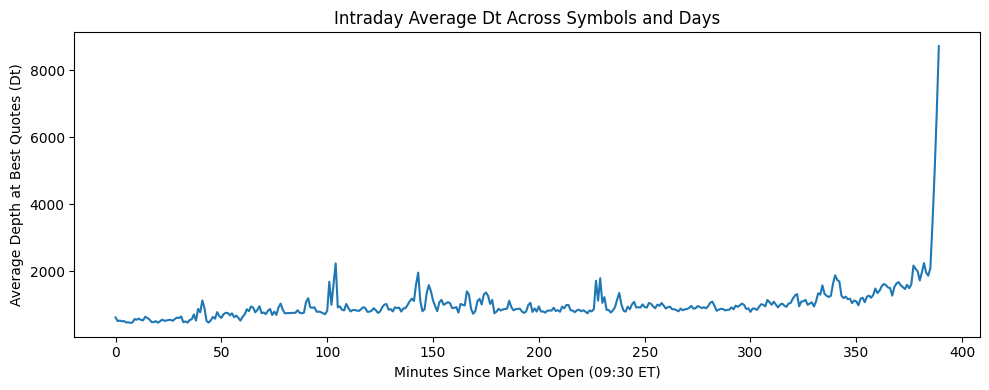

In [2]:
import matplotlib.pyplot as plt

# Reset the index to get symbol / ts_event_dt back as columns
df = df_indexed.reset_index()

# Make ts_event_dt timezone-aware ET in all cases
if df['ts_event_dt'].dt.tz is None:
    df['ts_event_dt'] = (
        df['ts_event_dt']
          .dt.tz_localize('UTC')            # assume current values are UTC
          .dt.tz_convert('America/New_York')
    )
else:
    df['ts_event_dt'] = df['ts_event_dt'].dt.tz_convert('America/New_York')

# Derive plain-date column if missing
if 'date' not in df.columns:
    df['date'] = df['ts_event_dt'].dt.date

# Floor to nearest minute
df['minute_bin'] = df['ts_event_dt'].dt.floor('min')

# First non‑zero ask_ct_N per row
ask_ct_cols = [f'ask_sz_{i:02d}' for i in range(10)]
def first_nonzero_depth(row):
    for col in ask_ct_cols:
        if col in row and row[col] > 0:
            return row[col]
    return 0
df['depth'] = df.apply(first_nonzero_depth, axis=1)

# Compute minute averages of Dt
minute_dt = (
    df.groupby(['symbol', 'date', 'minute_bin'])['depth']
      .mean()
      .reset_index(name='Dt')
)

# Minutes since 09:30 Eastern
minute_dt['minutes_since_open'] = (
    minute_dt['minute_bin'].dt.hour * 60
  + minute_dt['minute_bin'].dt.minute
  - (9 * 60 + 30)
)

# Keep regular session minutes
trading_dt = minute_dt[
    (minute_dt['minutes_since_open'] >= 0) &
    (minute_dt['minutes_since_open'] < 390)
]

# Average across symbols and days
avg_dt = (
    trading_dt.groupby('minutes_since_open')['Dt']
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(avg_dt['minutes_since_open'], avg_dt['Dt'])
plt.xlabel('Minutes Since Market Open (09:30 ET)')
plt.ylabel('Average Depth at Best Quotes (Dt)')
plt.title('Intraday Average Dt Across Symbols and Days')
plt.tight_layout()
plt.show()

Next, I fit a penalized cubic B-spline (P-spline) with six interval knots to the minute-level intraday average of Dt, choosing a smoothness penalty by generalized cross-validation. I then plot the fit against the raw minute averages. 

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:21: RuntimeWarning: divide by zero encountered in matmul
  XtX = Bx.T @ Bx + lam * (D.T @ D)
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:21: RuntimeWarning: overflow encountered in matmul
  XtX = Bx.T @ Bx + lam * (D.T @ D)
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:21: RuntimeWarning: invalid value encountered in matmul
  XtX = Bx.T @ Bx + lam * (D.T @ D)
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:22: RuntimeWarning: divide by zero encountered in matmul
  coef = np.linalg.solve(XtX, Bx.T @ y)
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:22: RuntimeWarning: overflow encountered in matmul
  coef = np.linalg.solve(XtX, Bx.T @ y)
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:22: RuntimeWarning: invalid value encountered in matmul
  coef = n

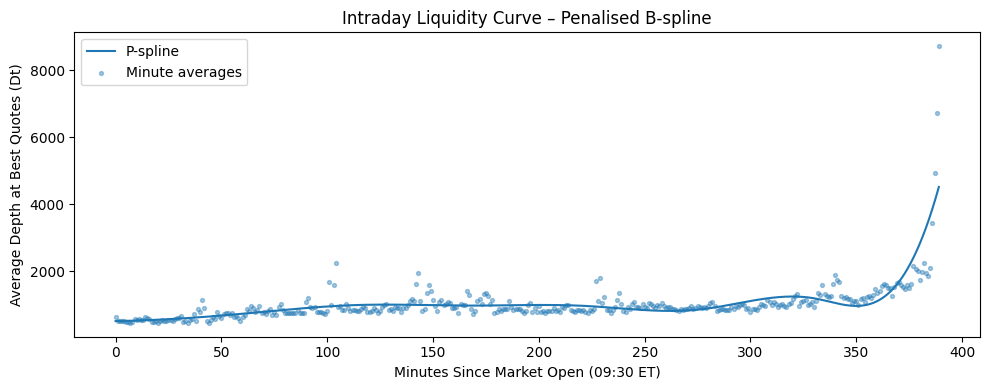

In [ ]:
import numpy as np
from patsy import dmatrix
import statsmodels.api as sm

# Minute grid and target
x = avg_dt['minutes_since_open'].to_numpy()    
y = avg_dt['Dt'].to_numpy()

# Low-rank cubic B-spline basis 
knots = np.linspace(60, 330, 6)                  
Bx = dmatrix("bs(x, knots=knots, degree=3, include_intercept=True)",
             {"x": x}, return_type='dataframe').to_numpy()

# Penalty matrix: second-order differences of coefficients
D = np.diff(np.eye(Bx.shape[1]), n=2, axis=0)
pen = 2                                          

# Generalised cross-validation to pick lambda (ridge-style)
lams = 10.0 ** np.linspace(-4, 4, 100)
gcv = []
for lam in lams:
    XtX = Bx.T @ Bx + lam * (D.T @ D)
    coef = np.linalg.solve(XtX, Bx.T @ y)
    hat = Bx @ np.linalg.solve(XtX, Bx.T)       
    rss = np.sum((y - Bx @ coef) ** 2)
    df1  = np.trace(hat)
    gcv.append(rss / (len(y) - df1) ** 2)
lam_opt = lams[np.argmin(gcv)]

# Re-fit with optimal lambda
XtX = Bx.T @ Bx + lam_opt * (D.T @ D)
coef = np.linalg.solve(XtX, Bx.T @ y)

# Callable spline, its derivative, and an antiderivative 
def _basis(t):
    return dmatrix("bs(t, knots=knots, degree=3, include_intercept=True)",
                   {"t": np.asarray(t)}, return_type='dataframe').to_numpy()

def Dt_hat(t):
    return _basis(t) @ coef

# First derivative via analytic derivative of B-spline basis
def _dbasis(t):
    return dmatrix("bs(t, knots=knots, degree=3, include_intercept=True, deriv=1)",
                   {"t": np.asarray(t)}, return_type='dataframe').to_numpy()

def dDt_dt(t):
    return _dbasis(t) @ coef

# Quick check: smooth curve vs. minute points
dense_x = np.linspace(0, 389, 390 * 60)
plt.figure(figsize=(10, 4))
plt.plot(dense_x, Dt_hat(dense_x), label='P-spline')
plt.scatter(x, y, s=8, alpha=0.4, label='Minute averages')
plt.xlabel('Minutes Since Market Open (09:30 ET)')
plt.ylabel('Average Depth at Best Quotes (Dt)')
plt.title('Intraday Liquidity Curve – Penalised B-spline')
plt.legend(); plt.tight_layout(); plt.show()

Next, I calculate each symbol's median half-spread during trading hours and take the median of those medians to get my global c. 

In [4]:
# Identify best-quote price columns
ask_px_col = 'ask_px_00'
bid_px_col = 'bid_px_00'

# Half-spread per event
df['half_sp'] = 0.5 * (df[ask_px_col] - df[bid_px_col])

# Keep regular session quotes (09:30–16:00 ET)
session_mask = (
    (df['ts_event_dt'].dt.time >= pd.Timestamp('09:30').time()) &
    (df['ts_event_dt'].dt.time <  pd.Timestamp('16:00').time())
)
session_df = df.loc[session_mask]

# Median half-spread per symbol
c_by_sym = (
    session_df.groupby('symbol', as_index=False)['half_sp']
              .median()
              .rename(columns={'half_sp': 'c'})
)

# Global median
c_global = c_by_sym['c'].median()
print(c_global)

0.030000000000001137


Now, we construct an impact curve by averaging, for each order size x, the premium gt(x) paid above the best ask across all snapshots, and then we fit and plot a power-law g(x) = ax^p against those averaged data on log-log axes. We filter out extreme bucket sizes because the data 

p = 0.455


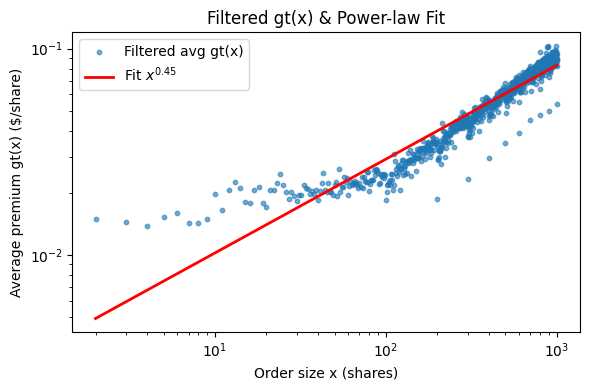

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build (x, gt) pairs from book snapshots
pairs = []
for _, row in session_df.iterrows():
    base = row['ask_px_00']
    cum_sz = 0.0
    cum_cost = 0.0
    for lvl in range(10):
        sz = row[f'ask_sz_{lvl:02d}']
        px = row[f'ask_px_{lvl:02d}']
        cum_sz += sz
        cum_cost += px * sz
        if lvl == 0:
            continue
        gt = cum_cost / cum_sz - base
        if gt > 0 and cum_sz > 0:
            pairs.append((cum_sz, gt))

raw = pd.DataFrame(pairs, columns=['x', 'gt'])

# Aggregate to get average gt for each integer size and count samples
raw['x_int'] = raw['x'].astype(int)
avg_df = (
    raw
    .groupby('x_int', as_index=False)
    .agg(gt_avg=('gt', 'mean'), n=('gt', 'count'))
)

# Filter out under-sampled and extreme-size buckets
filtered = avg_df[avg_df['x_int'] <= 1000]

# Fit power law to the filtered averaged curve
logx = np.log(filtered['x_int'].to_numpy())
logy = np.log(filtered['gt_avg'].to_numpy())
p, loga = np.polyfit(logx, logy, 1)   
print(f'p = {p:.3f}')

# Plot filtered average gt(x) and the fitted power-law
plt.figure(figsize=(6, 4))
plt.scatter(filtered['x_int'], filtered['gt_avg'], s=10, alpha=0.6, label='Filtered avg gt(x)')
x_fit = np.logspace(np.log10(filtered['x_int'].min()), np.log10(filtered['x_int'].max()), 200)
plt.plot(x_fit, np.exp(loga) * x_fit**p, 'r-', lw=2, label=f'Fit $x^{{{p:.2f}}}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Order size x (shares)')
plt.ylabel('Average premium gt(x) ($/share)')
plt.title('Filtered gt(x) & Power-law Fit')
plt.legend()
plt.tight_layout()
plt.show()

Finally, we use the mathematical method we decided was best to minimize the gt(x) function, using 390 xi's for each minite of the day to represent a chunk of S, the total number of shares we must buy throughout the day. This entails solving for the Lagrange multiplier lambda via bisection (using a flat marginal cost c up to depth Dt, and a power-law tail proportional to x^p) and then prints the optimal allocation vector and verifies its sum equals S.

In [6]:
import numpy as np

# Minute grid 0–389
x = np.arange(0, 390)
Dt = Dt_hat(x)
c = c_global
p = 0.45
a = c / Dt**p
T = len(Dt)
S = 10000

total_flat = Dt.sum()
if S <= total_flat:
    # All trades happen in flat region -> proportionally fill Dt
    x_opt = Dt * (S / total_flat)
else:
    # Need tail trades as well -> bisection on λ
    lam_lo = c
    lam_hi = (p+1) * a.max() * (S**p)
    def allocate(lam):
        if lam <= c:
            return Dt.copy()
        xtail = (lam / (a * (p+1)))**(1/p)
        return np.maximum(Dt, xtail)

    for _ in range(50):
        lam_mid = 0.5*(lam_lo + lam_hi)
        if allocate(lam_mid).sum() > S:
            lam_hi = lam_mid
        else:
            lam_lo = lam_mid

    lam_star = 0.5*(lam_lo + lam_hi)
    x_opt = allocate(lam_star)

print("Allocated shares per minute:", x_opt)
print("Check sum =", x_opt.sum())

Allocated shares per minute: [ 12.97345336  12.9992259   13.02775711  13.05901859  13.09298195
  13.12961877  13.16890067  13.21079923  13.25528607  13.30233278
  13.35191096  13.40399221  13.45854813  13.51555032  13.57497038
  13.63677991  13.70095052  13.76745379  13.83626134  13.90734475
  13.98067564  14.0562256   14.13396623  14.21386913  14.2959059
  14.38004814  14.46626745  14.55453544  14.64482369  14.73710382
  14.83134742  14.92752608  15.02561142  15.12557503  15.22738851
  15.33102346  15.43645149  15.54364418  15.65257315  15.76320998
  15.87552629  15.98949367  16.10508372  16.22226804  16.34101823
  16.46130589  16.58310263  16.70638003  16.83110971  16.95726326
  17.08481227  17.21372836  17.34398313  17.47554816  17.60839506
  17.74249544  17.87782088  18.014343    18.15203339  18.29086365
  18.43080538  18.57181779  18.7138105   18.85668074  19.00032574
  19.14464274  19.28952896  19.43488163  19.58059799  19.72657526
  19.87271067  20.01890146  20.16504486  20.3110

/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:39: RuntimeWarning: divide by zero encountered in matmul
  return _basis(t) @ coef
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:39: RuntimeWarning: overflow encountered in matmul
  return _basis(t) @ coef
/var/folders/8_/l7ym394s7wzd2wrk9f9333qh0000gn/T/ipykernel_15550/2757330266.py:39: RuntimeWarning: invalid value encountered in matmul
  return _basis(t) @ coef
